## 1. Evaluate different ML models on the same subset of features

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import rankdata
import matplotlib.pyplot as plt
from sksurv.util import Surv
from sksurv.metrics import cumulative_dynamic_auc, concordance_index_censored, concordance_index_ipcw
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, ComponentwiseGradientBoostingSurvivalAnalysis, GradientBoostingSurvivalAnalysis
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import joblib

In [2]:
print(plt.rcParams["font.family"])
plt.rcParams["font.sans-serif"] = ["Arial"] + plt.rcParams["font.sans-serif"]

['sans-serif']


In [3]:
# Load formatted cytokines data
df = pd.read_csv("../data/CV_plasma_Combined_formatted_20260731.csv")
df

,sample_names,sample_id,cohort,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,...,globalhealthstatusql2,qlq30score,hn35,pathologicstage,lvi,pni,survival_status,sx_to_lastfu,survival_2yrs,ss
0,FF301C,FF301C,LLU,29.45,25.24,90.00,6.40,3.95,4.21,3.54,...,75.00,81.62,30.56,stage_I,no,no,alive,1839,alive,1
1,FF302C,FF302C,LLU,71.50,9.93,46.35,0.00,0.00,2.33,3.42,...,16.67,46.11,47.78,stage_IVA,no,yes,alive,1721,alive,4
2,FF303C,FF303C,LLU,54.54,18.38,54.01,46.49,18.90,1.37,4.15,...,50.00,57.56,45.68,stage_IVA,yes,no,death,48,death,4
3,FF304C,FF304C,LLU,132.67,27.47,81.82,6.89,3.95,4.56,9.69,...,0.00,19.23,94.44,stage_IVA,no,yes,death,131,death,3
4,FF305C,FF305C,LLU,28.01,13.63,66.20,5.44,0.92,3.04,2.42,...,75.00,76.67,17.44,stage_II,no,no,alive,1679,alive,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,76,S0076,UAB,61.90,122.36,103.74,552.31,15.62,5864.00,199.75,...,NaN,NaN,NaN,stage_IVB,yes,yes,death,882,alive,3
208,77,S0077,UAB,18.86,91.86,71.49,22.67,5.42,146.71,18.96,...,NaN,NaN,NaN,stage_II,no,no,alive,1273,alive,1
209,78,S0078,UAB,12.99,66.46,51.61,9.46,2.89,28.61,2.28,...,NaN,NaN,NaN,stage_III,yes,yes,alive,1250,alive,4
210,79,S0079,UAB,13.66,75.02,40.79,8.96,3.81,38.38,5.04,...,NaN,NaN,NaN,stage_II,no,no,alive,1183,alive,2


In [4]:
# Specify lists of variables for analysis
clinicopathologic_vars = [
    "ages", "sex", "race", "tobaccouse", "alcoholuse",
    "pathologicstage", "lvi", "pni",
    "survival_status", "sx_to_lastfu", "survival_2yrs"
]
pain_scores = [
    "averageucsf", "spontaneouspain135", "functionalpain246", "bpiphysicalinterferences",
    "bpipsychologicalinterferences", "bpi_intensity", "functionalscores", "symptomscore",
    "globalhealthstatusql2", "qlq30score", "hn35"
]
cytokines = [
    "egf", "ifnalpha2",	"ifngamma",	"il1alpha",
    "il1beta", "il4", "il6", "il8",	"il10",
    "mip1alpha", "tgfalpha", "tnfalpha", "tnfbeta",
    "hbegf", "vegfc", "vegfd"
]

In [5]:
# Encode survival status as binary variable
df["survival_status_encoded"] = df["survival_status"].map({"alive": 0, "death": 1})

In [6]:
# Subset cytokines and cohort columns for analysis
cytokines_df = df.loc[:, cytokines + ["cohort", "ss", "survival_status_encoded", "sx_to_lastfu"]].drop(columns=["tgfalpha", "hbegf"])
cytokines_df

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tnfalpha,tnfbeta,vegfc,vegfd,cohort,ss,survival_status_encoded,sx_to_lastfu
0,29.45,25.24,90.00,6.40,3.95,4.21,3.54,4.14,3.92,25.93,18.74,10.46,381.47,263.05,LLU,1,0,1839
1,71.50,9.93,46.35,0.00,0.00,2.33,3.42,4.53,75.20,2.90,25.54,3.74,923.75,237.53,LLU,4,0,1721
2,54.54,18.38,54.01,46.49,18.90,1.37,4.15,3.57,98.33,25.05,22.39,4.83,490.19,130.47,LLU,4,1,48
3,132.67,27.47,81.82,6.89,3.95,4.56,9.69,7.29,20.63,20.32,28.18,9.32,1148.22,34.22,LLU,3,1,131
4,28.01,13.63,66.20,5.44,0.92,3.04,2.42,5.44,10.63,17.14,39.61,5.94,1113.45,142.55,LLU,1,0,1679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,61.90,122.36,103.74,552.31,15.62,5864.00,199.75,208.34,168.84,18.23,19.66,855.53,289.94,91.56,UAB,3,1,882
208,18.86,91.86,71.49,22.67,5.42,146.71,18.96,12.67,82.12,10.90,26.21,19.05,234.20,65.32,UAB,1,0,1273
209,12.99,66.46,51.61,9.46,2.89,28.61,2.28,8.89,7.41,9.54,13.77,7.24,144.61,55.09,UAB,4,0,1250
210,13.66,75.02,40.79,8.96,3.81,38.38,5.04,4.50,12.45,6.71,16.65,11.06,158.81,21.47,UAB,2,0,1183


In [7]:
y = Surv.from_arrays(
        event=cytokines_df["survival_status_encoded"],
        time=cytokines_df["sx_to_lastfu"]
)
y

array([(False, 1839.), (False, 1721.), ( True,   48.), ( True,  131.),
       (False, 1679.), ( True,  318.), ( True,  278.), (False, 1765.),
       (False, 1758.), ( True,  997.), ( True,  482.), ( True,  592.),
       (False, 1625.), (False, 1592.), (False, 1406.), ( True,   84.),
       ( True,  253.), ( True,   51.), (False, 1582.), (False, 1510.),
       (False, 1500.), (False, 1485.), (False, 1410.), (False, 1475.),
       ( True,  689.), ( True, 1055.), ( True,  433.), (False,  634.),
       ( True,  665.), (False, 1268.), ( True,  330.), (False, 1274.),
       (False, 1282.), (False,  765.), (False, 1123.), (False, 1094.),
       ( True,  618.), ( True,  490.), (False, 1137.), (False, 1095.),
       (False, 1050.), ( True,  494.), ( True,  597.), (False, 1085.),
       ( True,  379.), ( True,  355.), (False, 1078.), ( True,  385.),
       ( True,   87.), ( True,  763.), (False,  907.), (False,  814.),
       (False, 1018.), (False, 1014.), (False,  945.), (False,  631.),
      

In [9]:
def quantile_normalize_two_batches(values, batch_labels, ref_batch=None):
    """
    Quantile-normalize a single continuous variable measured on two platforms/batches.

    values: 1D array-like, the cytokine measurements across all samples
    batch_labels: array-like, same length, platform id per sample (e.g. 'A'/'B')
    ref_batch: which batch's distribution to use as the reference.
               If None, uses the pooled distribution of all samples as reference.
    """
    values = np.asarray(values, dtype=float)
    batch_labels = np.asarray(batch_labels)
    out = values.copy()

    if ref_batch is None:
        ref_sorted = np.sort(values)
    else:
        ref_sorted = np.sort(values[batch_labels == ref_batch])

    ref_quantiles = np.linspace(0, 1, len(ref_sorted))

    for b in np.unique(batch_labels):
        mask = batch_labels == b
        x = values[mask]
        ranks = rankdata(x, method="average")
        pct = (ranks - 0.5) / len(x)              # empirical percentile within its own batch
        out[mask] = np.interp(pct, ref_quantiles, ref_sorted)  # map to reference distribution

    return out

cytokine_cols = ["il6", "il8", "il10", "tnfalpha", "ss"]
cytokines_df_norm = cytokines_df.copy()

for col in cytokine_cols:
    cytokines_df_norm[col] = quantile_normalize_two_batches(
        cytokines_df[col], cytokines_df["cohort"], ref_batch="UAB"
    )

In [10]:
# Training cohort
cohort_train = "UAB"
X_train = cytokines_df_norm[cytokines_df_norm["cohort"] == cohort_train]
print(X_train.shape)

# Create structured array for survival analysis
y_train = Surv.from_arrays(
        event=X_train["survival_status_encoded"],
        time=X_train["sx_to_lastfu"]
    )

print(y_train.shape)

(100, 18)
(100,)


In [11]:
# Testing cohort
cohort_test = "LLU"
X_test = cytokines_df_norm[cytokines_df_norm["cohort"] == cohort_test]
print(X_test.shape)

# Create structured array for survival analysis
y_test = Surv.from_arrays(
        event=X_test["survival_status_encoded"],
        time=X_test["sx_to_lastfu"]
    )

print(y_test.shape)

(112, 18)
(112,)


In [12]:
# Specify numeric features for survival ML models
numeric_features = cytokines_df_norm.columns.drop(["cohort", "survival_status_encoded", "sx_to_lastfu"])
numeric_features

Index(['egf', 'ifnalpha2', 'ifngamma', 'il1alpha', 'il1beta', 'il4', 'il6',
       'il8', 'il10', 'mip1alpha', 'tnfalpha', 'tnfbeta', 'vegfc', 'vegfd',
       'ss'],
      dtype='object')

In [13]:
print(f"{cohort_train} - Training cohort size: {X_train.shape[0]} samples")
print(f"{cohort_test} - Testing cohort size: {X_test.shape[0]} samples")

UAB - Training cohort size: 100 samples
LLU - Testing cohort size: 112 samples


In [14]:
# Select features for survival ML models
selected_features = numeric_features.intersection(["il6", "il8", "il10", "tnfalpha", "ss"])
selected_features

Index(['il6', 'il8', 'il10', 'tnfalpha', 'ss'], dtype='object')

In [15]:
# Preprcessing
# train_sc = StandardScaler()
# test_sc = StandardScaler()
sc = StandardScaler()

X_train_transformed = sc.fit_transform(X_train[selected_features])
print(f"X-train-transformed: {X_train_transformed}")

X_test_transformed = sc.transform(X_test[selected_features])
print(f"X-test-transformed: {X_test_transformed}")

X-train-transformed: [[-3.86187454e-01 -4.28042467e-01  6.62623085e-02 -1.12471120e+00
   3.55377999e-01]
 [-3.19680119e-01 -3.85404128e-01 -4.83278600e-01 -4.42766644e-01
   3.55377999e-01]
 [ 4.04661900e+00  3.88158275e+00  2.34199376e+00 -1.89353972e-01
  -1.15686881e+00]
 [-4.43070405e-01 -4.94027600e-01 -4.52241588e-01  2.15120857e-01
   1.11150140e+00]
 [-3.90576348e-01 -3.06991301e-01 -5.34793999e-01  2.27321748e+00
   1.11150140e+00]
 [-4.00660076e-01 -3.90356772e-01 -4.80379006e-01 -6.11423455e-01
  -1.15686881e+00]
 [-4.41875110e-01 -4.63065084e-01 -2.91775387e-01  5.59825337e-01
  -4.00745403e-01]
 [-2.26738833e-01 -3.36201070e-01 -3.00908011e-01  5.85086628e-01
   1.11150140e+00]
 [-4.32016024e-01 -4.83279893e-01 -2.38473369e-01  3.70862051e-01
  -1.15686881e+00]
 [-3.14875470e-01 -4.08691096e-01 -1.86456399e-01  1.18701871e+00
   1.11150140e+00]
 [-1.64055284e-02 -9.52984980e-02  2.41993484e-01 -2.11416235e-01
  -4.00745403e-01]
 [-4.41875110e-01 -4.32933668e-01 -4.1850268

In [16]:
# # Sanity check: Ensure that the time range of the test data is within the time range of the training data
# y_events = y_train[y_train["event"]]
# train_min, train_max = y_events["time"].min(), y_events["time"].max()

# y_events = y_test[y_test["event"]]
# test_min, test_max = y_events["time"].min(), y_events["time"].max()

# assert (
#     train_min <= test_min < test_max < train_max
# ), "time range or test data is not within time range of training data."

In [17]:
# Evaluation times for time-dependent ROC (restricted to 2 years)
horizon_days = 365.24 * 2

# last time must be strictly below max follow-up
upper_time = min(
    horizon_days,
    np.nextafter(y_train["time"].max(), -np.inf),
    np.nextafter(y_test["time"].max(), -np.inf),
)

# use event-time quantiles from test set, then keep valid range
event_times_test = y_test["time"][y_test["event"]]
times = np.percentile(event_times_test, np.linspace(5, 95, 15))
times = np.unique(times[(times >= y_test["time"].min()) & (times <= upper_time)])

print(times)
print(f"Max evaluation time: {times.max():.1f} days (<= 2 years)")

[ 52.25        82.28571429 107.64285714 131.         197.14285714
 253.         260.25       268.         294.57142857 337.14285714
 391.07142857 482.57142857 588.5        615.        ]
Max evaluation time: 615.0 days (<= 2 years)


il6: mean AUC = 0.633
il8: mean AUC = 0.515
il10: mean AUC = 0.606
tnfalpha: mean AUC = 0.622
ss: mean AUC = 0.732


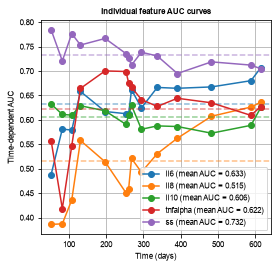

In [18]:
# Plot time-dependent AUC curves for individual features separately
plt.figure(figsize=(10.5, 10, "cm"))

X_test_arr = np.asarray(X_test_transformed)

for i, col in enumerate(selected_features):
    auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, X_test_arr[:, i], times)
    print(f"{col}: mean AUC = {mean_auc:.3f}")
    plt.plot(times, auc, marker="o", label=f"{col} (mean AUC = {mean_auc:.3f})")
    plt.axhline(mean_auc, linestyle="--", alpha=0.5, color=plt.gca().lines[-1].get_color())

plt.xlabel("Time (days)", fontsize=8)
plt.xticks(fontsize=8)
plt.ylabel("Time-dependent AUC", fontsize=8)
plt.yticks(fontsize=8)
plt.title("Individual feature AUC curves", fontsize=8, fontweight="bold")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True)

# plt.savefig("../figures/individual_feature_auc_curves.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [19]:
# CoxPH surival model
cph = CoxPHSurvivalAnalysis()
cph.fit(X_train_transformed, y_train)
c_index = cph.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

cph_risk_scores = cph.predict(X_test_transformed)
cph_auc, cph_mean_auc = cumulative_dynamic_auc(y_train, y_test, cph_risk_scores, times)
print(f"Mean AUC: {cph_mean_auc:.3f}")

C-index: 0.582
Mean AUC: 0.583


In [20]:
# Gradient-boosted CoxPH loss with regression trees as base learner
gbsa_tree = GradientBoostingSurvivalAnalysis(random_state=2026)
gbsa_tree.fit(X_train_transformed, y_train)
c_index = gbsa_tree.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

gbsa_tree_risk_scores = gbsa_tree.predict(X_test_transformed)
gbsa_tree_auc, gbsa_tree_mean_auc = cumulative_dynamic_auc(y_train, y_test, gbsa_tree_risk_scores, times)
print(f"Mean AUC: {gbsa_tree_mean_auc:.3f}")

C-index: 0.678
Mean AUC: 0.703


In [21]:
# Gradient boosting CoxPH with component-wise least squares as base learner
gbsa_ls = ComponentwiseGradientBoostingSurvivalAnalysis(random_state=2026)
gbsa_ls.fit(X_train_transformed, y_train)
cindex = gbsa_ls.score(X_test_transformed, y_test)
print(f"C-index: {round(cindex, 3)}")

gbsa_ls_risk_scores = gbsa_ls.predict(X_test_transformed)
gbsa_ls_auc, gbsa_ls_mean_auc = cumulative_dynamic_auc(y_train, y_test, gbsa_ls_risk_scores, times)
print(f"Mean AUC: {gbsa_ls_mean_auc:.3f}")

C-index: 0.717
Mean AUC: 0.733


In [22]:
# Random Survival Forest (RSF) model
rsf = RandomSurvivalForest(
    random_state=2026
)
rsf.fit(X_train_transformed, y_train)
c_index = rsf.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

rsf_risk_scores = rsf.predict(X_test_transformed)
rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times)
print(f"Mean AUC: {rsf_mean_auc:.3f}")

C-index: 0.687
Mean AUC: 0.728


In [23]:
# Permutation-based feature importance
result = permutation_importance(rsf, X_test_transformed, y_test, n_repeats=15, random_state=2026)

pd.DataFrame(
    {
        "importances_mean": result["importances_mean"],
        "importances_std": result["importances_std"],
    },
    index=selected_features,
).sort_values(by="importances_mean", ascending=False)


,importances_mean,importances_std
ss,0.137720,0.042452
tnfalpha,0.032445,0.009648
il8,0.015646,0.017997
il10,0.009980,0.008594
il6,-0.002646,0.008857


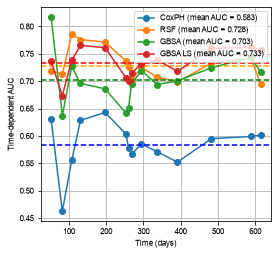

In [24]:
# Plot all models together for comparison
plt.figure(figsize=(10.5, 10, "cm"))

plt.plot(times, cph_auc, "o-", label=f"CoxPH (mean AUC = {cph_mean_auc:.3f})")
plt.axhline(cph_mean_auc, color="blue", linestyle="--",)
plt.plot(times, rsf_auc, "o-", label=f"RSF (mean AUC = {rsf_mean_auc:.3f})")
plt.axhline(rsf_mean_auc, color="orange", linestyle="--",)
plt.plot(times, gbsa_tree_auc, "o-", label=f"GBSA (mean AUC = {gbsa_tree_mean_auc:.3f})")
plt.axhline(gbsa_tree_mean_auc, color="green", linestyle="--",)
plt.plot(times, gbsa_ls_auc, "o-", label=f"GBSA LS (mean AUC = {gbsa_ls_mean_auc:.3f})")
plt.axhline(gbsa_ls_mean_auc, color="red", linestyle="--",)
plt.xlabel("Time (days)", fontsize=8)
plt.xticks(fontsize=8)
plt.ylabel("Time-dependent AUC", fontsize=8)
plt.yticks(fontsize=8)
# plt.title("Time-dependent AUC by subset model", fontsize=8, fontweight="bold")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True)

# plt.savefig("../figures/time_dependent_auc_subset_model_within2yrs.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 2. Evaluate the RSF model on different subsets of features

In [25]:
# Define a function to run RSF on a given feature set
def run_rsf(feature_set, cols, numeric_features, X_train, y_train, X_test, y_test, times):
    """Train/evaluate an RSF model on one feature subset. Returns a dict
    with the model, C-index, AUC curve, and mean AUC."""
    
    # Select subset of features for survival ML models
    selected_features = numeric_features.intersection(cols)
    
    # Preprocessing
    sc = StandardScaler()

    X_train_transformed = sc.fit_transform(X_train[selected_features])
    X_test_transformed = sc.transform(X_test[selected_features])
    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Testing set size: {X_test.shape[0]} samples")

    # Random Survival Forest (RSF) model
    rsf = RandomSurvivalForest(
        n_estimators=100,
        max_depth=4,
        min_samples_leaf=8,
        min_samples_split=2,
        max_features="sqrt",
        random_state=2026
    )

    rsf.fit(X_train_transformed, y_train)
    c_index = rsf.score(X_test_transformed, y_test)

    model_risk_scores = rsf.predict(X_test_transformed)
    rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(y_train, y_test, model_risk_scores, times)

    print(f"[{feature_set}] features: {selected_features}")
    print(f"[{feature_set}] C-index: {c_index:.3f} | Mean AUC: {rsf_mean_auc:.3f}")

    return {
        "feature_set": feature_set,
        "features": selected_features,
        "model": rsf,
        "c_index": c_index,
        "auc": rsf_auc,
        "mean_auc": rsf_mean_auc
    }

In [48]:
# Define a function to run RSF on all feature sets and plot AUC curves
def run_all(feature_sets, numeric_features, X_train, y_train, X_test, y_test, times, data_dir, fig_dir, color_map, **kwargs):
    """Run `run_rsf` for every {feature_set: cols} pair. Returns (results, summary_df)
    and plots all AUC curves together on one figure."""

    results = [
        run_rsf(feature_set, cols, numeric_features, X_train, y_train, X_test, y_test, times, **kwargs)
        for feature_set, cols in feature_sets.items()
    ]

    summary_df = pd.DataFrame([
        {
            "feature_set": res["feature_set"], 
            "n_features": len(res["features"]),
            "features": ", ".join(res["features"]),
            "c_index": round(res["c_index"], 3),
            "mean_auc": round(res["mean_auc"], 3)
        }
        for res in results
    ]).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    summary_df.to_csv(f"{data_dir}/rsf-feature-sets_uab-training_llu-validation_summary.csv", index=False)

    # Sort results by mean_auc descending for legend ordering
    results_sorted = sorted(results, key=lambda x: x["mean_auc"], reverse=True)
    
    plt.figure(figsize=(3.75, 8.5/2, "in"), dpi=300)
    for res in results_sorted:
        set_name = res["feature_set"]
        line_color = color_map.get(set_name) if color_map else None

        line, = plt.plot(
            times,
            res["auc"],
            marker="o",
            linestyle="-",
            color=line_color,
            label=f'{", ".join(res["features"])} (mean AUC = {res["mean_auc"]:.3f})',
        )
        plt.axhline(
            res["mean_auc"],
            color=line.get_color(),
            linestyle="--",
        )
    plt.xlabel("Time (days)", fontsize=8)
    plt.xticks(fontsize=8)
    plt.ylabel("Time-dependent AUC", fontsize=8)
    plt.yticks(fontsize=8)
    plt.title("UAB: Training set, LLU: Independent validation set", fontsize=8, fontweight="bold")
    plt.legend(loc="upper center", fontsize=8, bbox_to_anchor=(0.5, -0.15))
    plt.grid(True)
    
    plt.savefig(f"{fig_dir}/time-dependent-auc_rsf-feature-comparisons_uab-training_llu-validation_within2yrs.pdf", dpi=300, bbox_inches="tight", facecolor="white")
    
    plt.show()
    
    return results, summary_df

In [49]:
# Specify feature sets for RSF model evaluation
feature_sets = {
    "set_01": ["ss"],
    "set_02": ["ss", "il6", "il8", "il10", "tnfalpha"],
    "set_03": ["ss", "il6", "il10", "tnfalpha"],
    "set_04": ["ss", "il8", "il10", "tnfalpha"],
    "set_05": ["ss", "il10", "tnfalpha"],
}

feature_set_colors = {
    "set_01": "#E64B35FF",
    "set_02": "#4DBBD5FF",
    "set_03": "#00A087FF",
    "set_04": "#3C5488FF",
    "set_05": "#F39B7FFF",
}

Training set size: 100 samples
Testing set size: 112 samples
[set_01] features: Index(['ss'], dtype='object')
[set_01] C-index: 0.688 | Mean AUC: 0.733
Training set size: 100 samples
Testing set size: 112 samples
[set_02] features: Index(['il6', 'il8', 'il10', 'tnfalpha', 'ss'], dtype='object')
[set_02] C-index: 0.701 | Mean AUC: 0.755
Training set size: 100 samples
Testing set size: 112 samples
[set_03] features: Index(['il6', 'il10', 'tnfalpha', 'ss'], dtype='object')
[set_03] C-index: 0.721 | Mean AUC: 0.783
Training set size: 100 samples
Testing set size: 112 samples
[set_04] features: Index(['il8', 'il10', 'tnfalpha', 'ss'], dtype='object')
[set_04] C-index: 0.724 | Mean AUC: 0.776
Training set size: 100 samples
Testing set size: 112 samples
[set_05] features: Index(['il10', 'tnfalpha', 'ss'], dtype='object')
[set_05] C-index: 0.746 | Mean AUC: 0.795


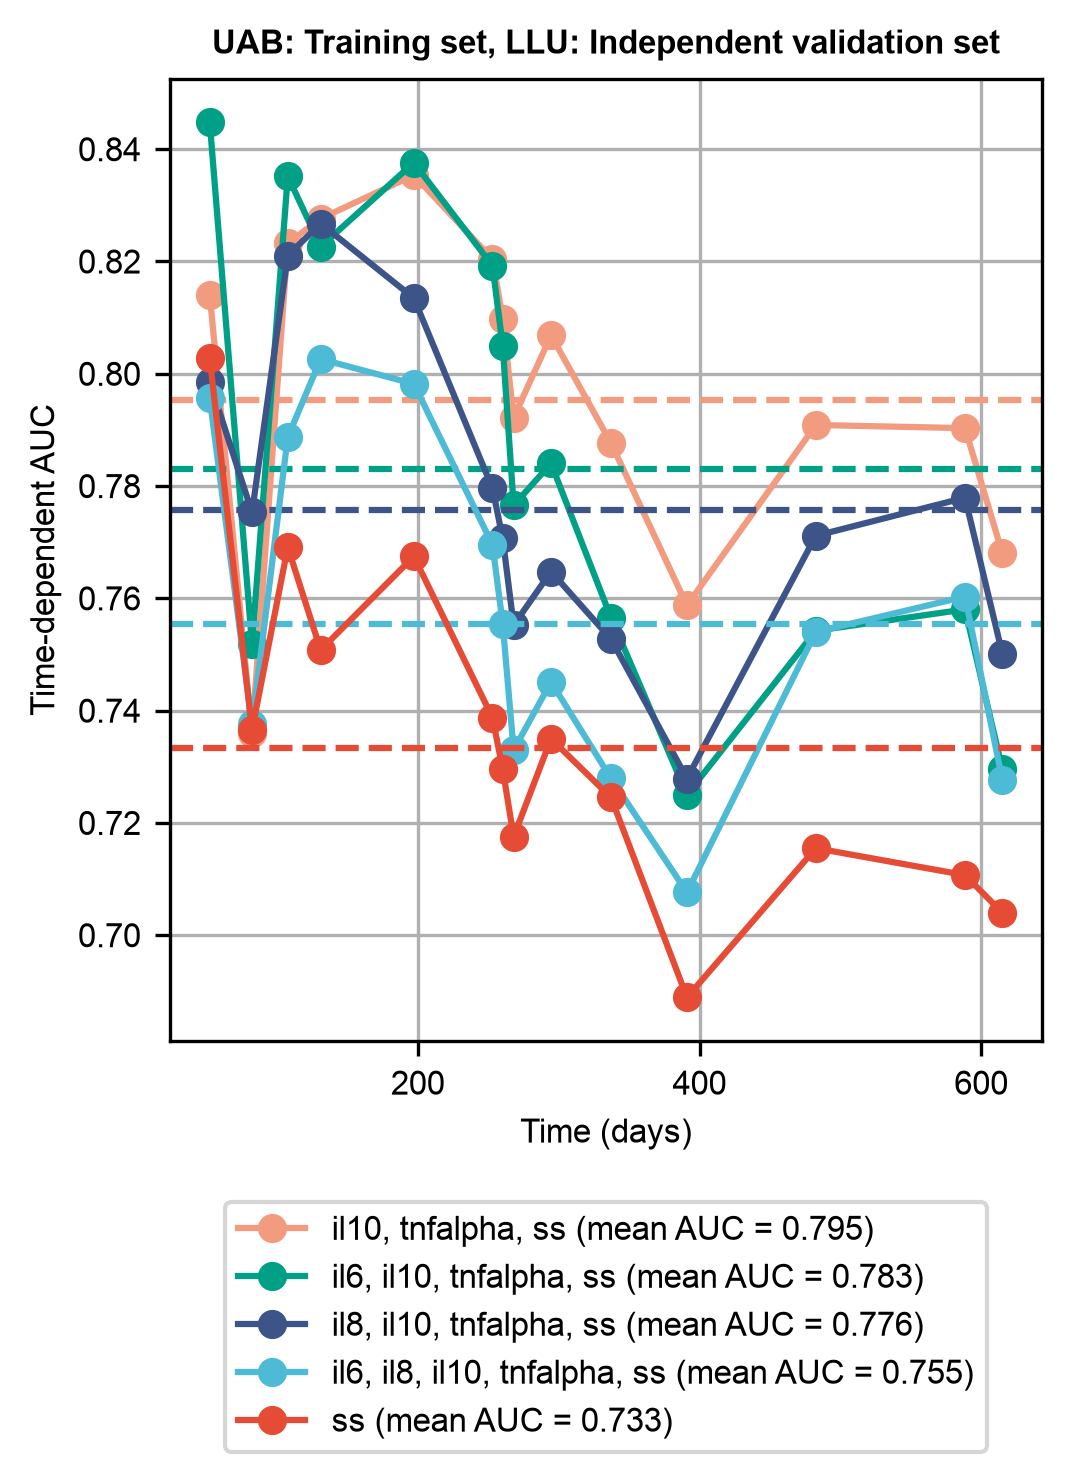

,feature_set,n_features,features,c_index,mean_auc
0,set_05,3,"il10, tnfalpha, ss",0.746,0.795
1,set_03,4,"il6, il10, tnfalpha, ss",0.721,0.783
2,set_04,4,"il8, il10, tnfalpha, ss",0.724,0.776
3,set_02,5,"il6, il8, il10, tnfalpha, ss",0.701,0.755
4,set_01,1,ss,0.688,0.733


In [50]:
results, summary_df = run_all(
    feature_sets, numeric_features, X_train, y_train, X_test, y_test, times,
    color_map=feature_set_colors,
    data_dir="../data_processed", fig_dir="../figures"
)
summary_df

In [51]:
selected_features = numeric_features.intersection(["ss", "il10", "tnfalpha"])
selected_features

Index(['il10', 'tnfalpha', 'ss'], dtype='object')

In [52]:
# Preprcessing
# train_sc = StandardScaler()
# test_sc = StandardScaler()
sc = StandardScaler()

X_train_transformed = sc.fit_transform(X_train[selected_features])
print(X_train_transformed.shape)

X_test_transformed = sc.transform(X_test[selected_features])
print(X_test_transformed.shape)

(100, 3)
(112, 3)


In [53]:
# Random Survival Forest (RSF) model
model = RandomSurvivalForest(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=8,
    min_samples_split=2,
    max_features="sqrt",
    random_state=2026
)

model.fit(X_train_transformed, y_train)
c_index = model.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

model_risk_scores = model.predict(X_test_transformed)
model_auc, model_mean_auc = cumulative_dynamic_auc(y_train, y_test, model_risk_scores, times)
print(f"Mean AUC: {model_mean_auc:.3f}")

C-index: 0.746
Mean AUC: 0.795


In [121]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, as_cumulative_dynamic_auc_scorer

# space = {
#     "n_estimators": hp.quniform("n_estimators", 50, 500, 25),
#     "max_depth": hp.choice("max_depth", [None, 3, 5, 7, 10]),
#     "min_samples_leaf": hp.quniform("min_samples_leaf", 5, 50, 5),
#     "min_samples_split": hp.quniform("min_samples_split", 2, 20, 2),
#     "max_features": hp.choice("max_features", ["sqrt", "log2", None]),
# }

space = {
    "alpha": hp.uniform("alpha", 0.01, 1.0),
    "ties": hp.choice("ties", ["breslow", "efron"]),
}

lower, upper = np.percentile(y_train["time"], [10, 90])
eval_times = np.arange(lower, upper + 1)

def objective(params):
    # params = {
    #     "n_estimators": int(params["n_estimators"]),
    #     "max_depth": params["max_depth"],
    #     "min_samples_leaf": int(params["min_samples_leaf"]),
    #     "min_samples_split": int(params["min_samples_split"]),
    #     "max_features": params["max_features"],
    #     "random_state": 2026,
    #     "n_jobs": -1,
    # }
    
    params = {
        "alpha": params["alpha"],
        "ties": params["ties"]
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)
    fold_scores = []

    for train_idx, val_idx in skf.split(X_train_transformed, y_train["event"]):
        X_tr, X_val = X_train_transformed[train_idx], X_train_transformed[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = CoxPHSurvivalAnalysis(**params)
        wrapped = as_cumulative_dynamic_auc_scorer(model, eval_times)
        wrapped.fit(X_tr, y_tr)

        fold_scores.append(wrapped.score(X_val, y_val))

    mean_cv_score = np.mean(fold_scores)
    return {"loss": -mean_cv_score, "status": STATUS_OK}

trials = Trials()
best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(2026),
)

print("Best hyperparameters:", best_params)

100%|██████████| 50/50 [00:07<00:00,  6.69trial/s, best loss: -0.7702909131385036]
Best hyperparameters: {'alpha': np.float64(0.8624618869984402), 'ties': np.int64(0)}


## 3. Hyperparameter tuning of the RSF model on the best subset of features

In [46]:
# Best subset of features for RSF model
selected_features = numeric_features.intersection(feature_sets["set_06"])
print(f"Selected features for ML model: {selected_features}")

# `selected_features` is a pandas Index; convert to list before adding "cohort"
feature_cols = selected_features.tolist() + ["cohort"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    cytokines_df[feature_cols],
    y,
    test_size=0.2,
    random_state=2024,
    stratify=y["event"],
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Preprcessing
# Fit one scaler per cohort on the training set, store them explicitly
cohort_scalers = {}
for cohort, group in X_train.groupby("cohort"):
    sc = StandardScaler()
    sc.fit(group[selected_features])
    cohort_scalers[cohort] = sc

def apply_cohort_scaling(X, scalers, feature_cols):
    parts = []
    for cohort, group in X.groupby("cohort"):
        transformed = scalers[cohort].transform(group[feature_cols])
        parts.append(pd.DataFrame(transformed, columns=feature_cols, index=group.index))
    return pd.concat(parts).loc[X.index]

X_train_transformed = apply_cohort_scaling(X_train, cohort_scalers, selected_features)
X_test_transformed = apply_cohort_scaling(X_test, cohort_scalers, selected_features)

# Random Survival Forest (RSF) model
rsf = RandomSurvivalForest(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=30,
    min_samples_split=2,
    max_features="sqrt",
    random_state=2026
)
rsf.fit(X_train_transformed, y_train)

c_index = rsf.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

rsf_risk_scores = rsf.predict(X_test_transformed)
rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times)
print(f"Mean AUC: {rsf_mean_auc:.3f}")

Selected features for ML model: Index(['il10', 'tnfalpha', 'ss'], dtype='object')
Training set size: 169 samples
Test set size: 43 samples
C-index: 0.766
Mean AUC: 0.853


RSF params:
- n_estimators: 200
- max_depth: None
- min_samples_leaf: 30
- min_samples_split: 2
- max_features: "sqrt"
- the rests are default values

In [48]:
# Save the RSF model and related artifacts for future use
artifact = {
    "model": rsf,
    "cohort_scalers": cohort_scalers,
    "selected_features": list(selected_features),
    "X_train": X_train_transformed,
    "X_test": X_test_transformed,
    "y_train": y_train,
    "y_test": y_test,
    "times": times,
    "c_index": c_index,
    "mean_auc": rsf_mean_auc,
    "sksurv_version": __import__("sksurv").__version__,
    "sklearn_version": __import__("sklearn").__version__,
}

joblib.dump(artifact, "../data_processed/rsf_bundle.joblib")

['../data_processed/rsf_bundle.joblib']